<a href="https://colab.research.google.com/github/opeyemijanet/Income-Food-Affordability-Dietary-Behavior-Analysis-A-Data-Driven-Public-Health-Study/blob/main/Food_Affordability_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- STEP 3: Define the path to your shared folder ---
data_path = '/content/drive/MyDrive/moviess/'

In [ ]:
# Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Does eating healthy depend on what’s in your wallet? While some believe nutritious food is a luxury reserved for those who can afford it, others argue that education, accessibility, and policy interventions play an even bigger role.

As part of a public health research team, your mission is to uncover the real factors driving food choices. Are healthier foods truly more expensive, or do regional access, income distribution, and availability have a greater impact?

Your insights could help shape smarter food policies, making healthy eating more affordable and accessible for all. Are you ready to dig into the data and make a real-world impact?

RESEARCH QUESTIONS

How does household income relate to the affordability of different food categories?

Do higher-income households buy healthier foods?

Are there geographic trends in food affordability?

Create at least one chart to highlight key insights.
Are healthier foods more expensive than processed options?


In [ ]:
# Define the file names - using the exact names from the directory listing
income_file = "Income-Expenditure.csv"
survey_file = "dietary habits survey data.csv"
prices_file = "Food Prices.csv" # Corrected filename
food_dim_file = "Food_Prices_Dimension_Table.csv"
# Note: There is also 'Food_Prices_Dimension_Table.csv' which is not being loaded currently.

# --- STEP 4: Load the datasets ---
income_df = pd.read_csv(data_path + income_file)
survey_df = pd.read_csv(data_path + survey_file)
prices_df = pd.read_csv(data_path + prices_file)
food_dim_df = pd.read_csv(data_path + food_dim_file)

# --- STEP 5: Quick sanity check ---
print("Income-Expenditure shape:", income_df.shape)
print("Dietary Habits shape:", survey_df.shape)
print("Food Prices shape:", prices_df.shape)

# Display first few rows
display(income_df.head())
display(survey_df.head())
display(prices_df.head())
display(food_dim_df.head())

Income-Expenditure shape: (50, 7)
Dietary Habits shape: (78, 27)
Food Prices shape: (1020600, 6)


,Mthly_HH_Income,Mthly_HH_Expense,No_of_Fly_Members,Emi_or_Rent_Amt,Annual_HH_Income,Highest_Qualified_Member,No_of_Earning_Members
0,5000,8000,3,2000,64200,Under-Graduate,1
1,6000,7000,2,3000,79920,Illiterate,1
2,10000,4500,2,0,112800,Under-Graduate,1
3,10000,2000,1,0,97200,Illiterate,1
4,12500,12000,2,3000,147000,Graduate,1


,Age,Gender,How many meals do you have a day? (number of regular occasions in a day when a significant and reasonably filling amount of food is eaten),What would best describe your diet:,Choose all that apply: [I skip meals],Choose all that apply: [I experience feelings of hunger during the day],Choose all that apply: [I consult a nutritionist/dietician],Choose all that apply: [I cook my own meals],What would you consider to be the main meal of YOUR day?,What does your diet mostly consist of and how is it prepared?,...,What is your weekly food intake frequency of the following food categories: [Meat],What is your weekly food intake frequency of the following food categories: [Seafood ],How frequently do you consume these beverages [Tea],How frequently do you consume these beverages [Coffee],How frequently do you consume these beverages [Aerated (Soft) Drinks],How frequently do you consume these beverages [Fruit Juices (Fresh/Packaged)],"How frequently do you consume these beverages [Dairy Beverages (Milk, Milkshakes, Smoothies, Buttermilk, etc)]",How frequently do you consume these beverages [Alcoholic Beverages],"What is your water consumption like (in a day, 1 cup=250ml approx)",
0,18-24,Male,5,Pollotarian (Vegetarian who consumes poultry a...,Rarely,Often,Never,Sometimes,Lunch,Freshly home-cooked produce,...,Often,Often,Never,Never,Less often,Never,Less often,Never,More than 15 cups,NaN
1,18-24,Male,4,Vegetarian (No egg or meat),Rarely,Often,Rarely,Rarely,Lunch,Freshly home-cooked produce,...,Never,Never,Less often,Never,Often,Once a day,Often,Never,11-14 cups,NaN
2,45-54,Male,3,Pescatarian (Vegetarian who consumes only seaf...,Never,Rarely,Never,Never,All,Freshly home-cooked produce,...,Never,Often,Once a day,Less often,Never,Less often,Once a day,Never,More than 15 cups,NaN
3,18-24,Male,2,Non-Vegetarian,Often,Often,Never,Sometimes,Lunch,Freshly home-cooked produce,...,Once a day,Few times a week,Few times a week,Once a day,Once a month,Once a month,Few times a week,Never,7-10 cups,NaN
4,18-24,Female,3,Eggetarian (Vegetarian who consumes egg and eg...,Sometimes,Sometimes,Never,Often,Breakfast,Freshly home-cooked produce,...,Never,Never,Never,Never,Once a month,Once a month,Once a day,Once a month,4-6 cups,NaN


,Year,Month,EFPG_code,Metroregion_code,Attribute,Value
0,2012,1,10000,National,Total weighted monthly sales in U.S. dollars,2.493734e+08
1,2012,1,10000,National,Total weighted monthly quantities in grams,4.875195e+10
2,2012,1,10000,National,Total unweighted monthly sales in U.S. dollars,1.629852e+08
3,2012,1,10000,National,Total unweighted monthly quantities in grams,3.217558e+10
4,2012,1,10000,National,Number of stores in geographic area,4.178100e+04


,EFPG_code,EFPG_name,Tier 1 group,Tier 2 group
0,10000,Whole-grain breads,Grains,"Whole-grain breads, cereal, rice, pasta, and f..."
1,10025,Whole-grain rice and pasta,Grains,"Whole-grain breads, cereal, rice, pasta, and f..."
2,10050,Whole-grain breakfast grains,Grains,"Whole-grain breads, cereal, rice, pasta, and f..."
3,10075,"Whole-grain flour, bread mixes, and frozen dough",Grains,"Whole-grain breads, cereal, rice, pasta, and f..."
4,15000,Non-whole-grain breads,Grains,"Non-whole-grain breads, cereal, rice, pasta, a..."


DATA UNDERSTANDING

In [ ]:
# Inspect the survey_df DataFrame
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 27 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   Age                                                                                                                                         78 non-null     object 
 1   Gender                                                                                                                                      78 non-null     object 
 2   How many meals do you have a day? (number of regular occasions in a day when a significant and reasonably filling amount of food is eaten)  78 non-null     int64  
 3   What would best describe your diet:            

In [ ]:
survey_df.head()

,Age,Gender,How many meals do you have a day? (number of regular occasions in a day when a significant and reasonably filling amount of food is eaten),What would best describe your diet:,Choose all that apply: [I skip meals],Choose all that apply: [I experience feelings of hunger during the day],Choose all that apply: [I consult a nutritionist/dietician],Choose all that apply: [I cook my own meals],What would you consider to be the main meal of YOUR day?,What does your diet mostly consist of and how is it prepared?,...,What is your weekly food intake frequency of the following food categories: [Meat],What is your weekly food intake frequency of the following food categories: [Seafood ],How frequently do you consume these beverages [Tea],How frequently do you consume these beverages [Coffee],How frequently do you consume these beverages [Aerated (Soft) Drinks],How frequently do you consume these beverages [Fruit Juices (Fresh/Packaged)],"How frequently do you consume these beverages [Dairy Beverages (Milk, Milkshakes, Smoothies, Buttermilk, etc)]",How frequently do you consume these beverages [Alcoholic Beverages],"What is your water consumption like (in a day, 1 cup=250ml approx)",
0,18-24,Male,5,Pollotarian (Vegetarian who consumes poultry a...,Rarely,Often,Never,Sometimes,Lunch,Freshly home-cooked produce,...,Often,Often,Never,Never,Less often,Never,Less often,Never,More than 15 cups,NaN
1,18-24,Male,4,Vegetarian (No egg or meat),Rarely,Often,Rarely,Rarely,Lunch,Freshly home-cooked produce,...,Never,Never,Less often,Never,Often,Once a day,Often,Never,11-14 cups,NaN
2,45-54,Male,3,Pescatarian (Vegetarian who consumes only seaf...,Never,Rarely,Never,Never,All,Freshly home-cooked produce,...,Never,Often,Once a day,Less often,Never,Less often,Once a day,Never,More than 15 cups,NaN
3,18-24,Male,2,Non-Vegetarian,Often,Often,Never,Sometimes,Lunch,Freshly home-cooked produce,...,Once a day,Few times a week,Few times a week,Once a day,Once a month,Once a month,Few times a week,Never,7-10 cups,NaN
4,18-24,Female,3,Eggetarian (Vegetarian who consumes egg and eg...,Sometimes,Sometimes,Never,Often,Breakfast,Freshly home-cooked produce,...,Never,Never,Never,Never,Once a month,Once a month,Once a day,Once a month,4-6 cups,NaN


In [ ]:
income_df.dtypes

,0
Mthly_HH_Income,int64
Mthly_HH_Expense,int64
No_of_Fly_Members,int64
Emi_or_Rent_Amt,int64
Annual_HH_Income,int64
Highest_Qualified_Member,object
No_of_Earning_Members,int64


In [ ]:
#check for null values
income_df.isnull().sum()

,0
Mthly_HH_Income,0
Mthly_HH_Expense,0
No_of_Fly_Members,0
Emi_or_Rent_Amt,0
Annual_HH_Income,0
Highest_Qualified_Member,0
No_of_Earning_Members,0


income dataframe have the right datatypeand there are no null values

In [ ]:
#create new columns for disposable income and food expenses proportion
income_df['disposable_income'] = income_df['Mthly_HH_Income'] - income_df['Mthly_HH_Expense']
income_df['food_exp_proportion'] = income_df['Mthly_HH_Expense'] * 0.2

In [ ]:
#summary statistics for income, expense and disposable income
print(income_df[['Mthly_HH_Income', 'Mthly_HH_Expense', 'disposable_income']].describe())



       Mthly_HH_Income  Mthly_HH_Expense  disposable_income
count        50.000000         50.000000          50.000000
mean      41558.000000      18818.000000       22740.000000
std       26097.908979      12090.216824       20434.804244
min        5000.000000       2000.000000       -3000.000000
25%       23550.000000      10000.000000        8250.000000
50%       35000.000000      15500.000000       17000.000000
75%       50375.000000      25000.000000       31000.000000
max      100000.000000      50000.000000       73000.000000


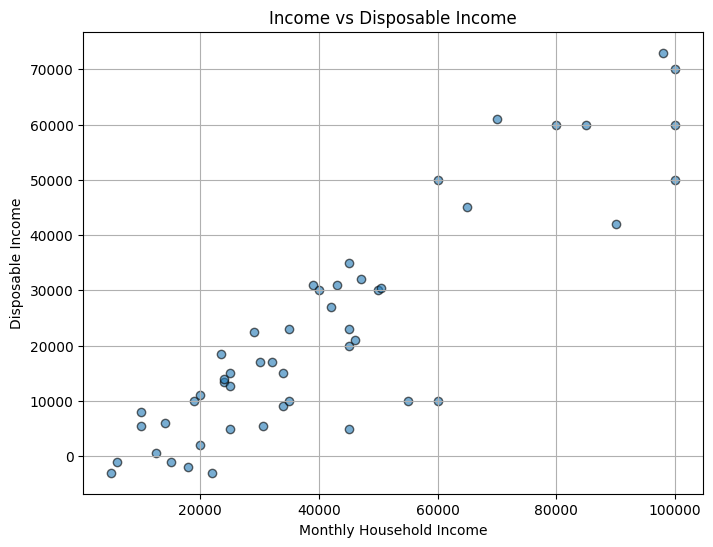

In [ ]:
#visualize income vs disposable income
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(income_df["Mthly_HH_Income"], income_df["disposable_income"], alpha=0.6, edgecolor='k')
plt.title("Income vs Disposable Income")
plt.xlabel("Monthly Household Income")
plt.ylabel("Disposable Income")
plt.grid(True)
plt.show()

ANALYSE FOOD PRICES DATASET

In [ ]:
prices_df.dtypes

,0
Year,int64
Month,int64
EFPG_code,int64
Metroregion_code,object
Attribute,object
Value,float64


In [ ]:
#convert year and month to datetime
prices_df["Year"] = pd.to_datetime(prices_df["Year"], format='%Y')
prices_df["Month"] = pd.to_datetime(prices_df["Month"], format='%m')



In [ ]:
#merge food prices and dimension table to get food category names
prices_df_merge= prices_df.merge(food_dim_df, on='EFPG_code', how='left')


In [ ]:
#filter for monthly sales in US dollars
price_filter = prices_df_merge[prices_df_merge['Attribute'] == 'Total weighted monthly sales in U.S. dollars']

In [ ]:
#group by food category and region to get average prices
price_summary = price_filter.groupby(['Tier 1 group', 'Metroregion_code'])['Value'].mean().reset_index()
price_value = price_summary['Value'] /1e6

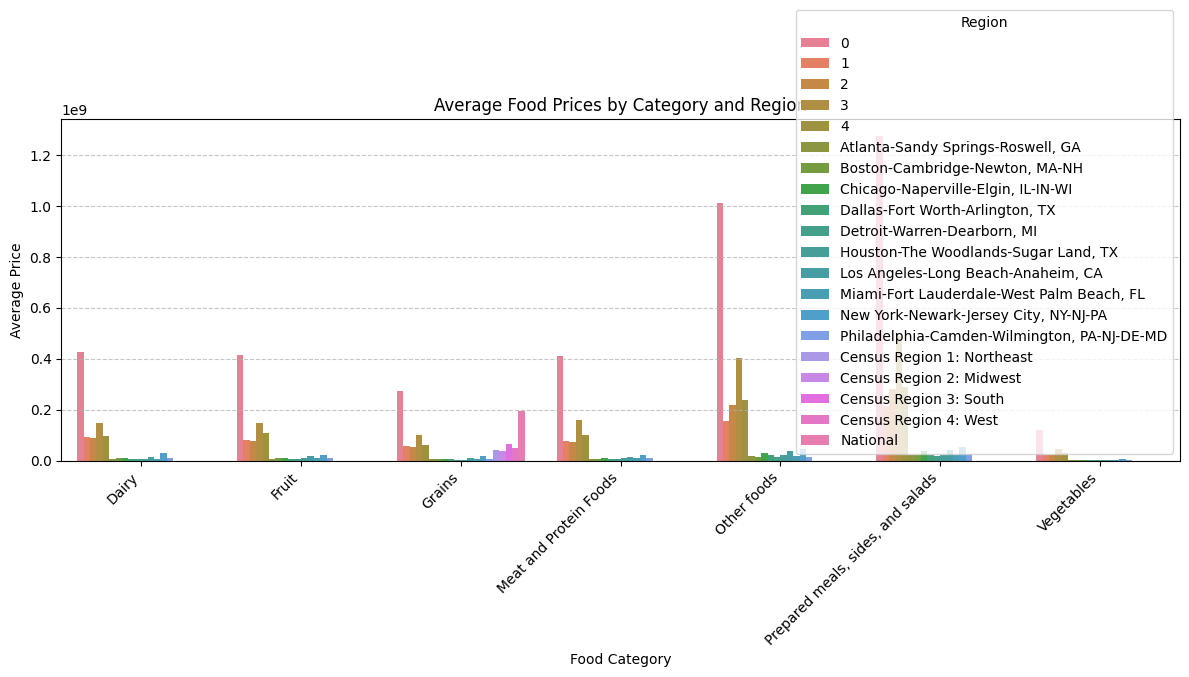

In [ ]:
#visualize food prices by category and region
plt.figure(figsize=(12, 6))
sns.barplot(data=price_summary,
            x='Tier 1 group',
            y='Value',
            hue='Metroregion_code')

plt.title('Average Food Prices by Category and Region')
plt.xlabel('Food Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Region')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#estimate food affordability
avg_price_cost = price_summary.groupby('Metroregion_code')['Value'].sum().reset_index()
avg_price_cost.columns = ['Metroregion_code', 'Avg_food_basket_cost'] #value is changed to avg_food_basket_cost
#merge with income expenditure data
national_price_cost = avg_price_cost.loc[avg_price_cost['Metroregion_code'] == 'National', 'Avg_food_basket_cost'].iloc[0]
income_df['food_affordability_ratio'] = income_df['disposable_income']/ (national_price_cost * 1e6 / 12) #i think it should be monthly income/cost

In [ ]:
#categorize affordability
def categorize_affordability(ratio):
  if ratio < 0:
    return 'cannot_afford(negative disposable income)'
  elif ratio < 1:
    return 'low_affordability'
  elif ratio < 2:
    return 'Moderate_affordability'
  else:
    return 'high_affordability'


In [ ]:
income_df['Affordability_category'] = income_df['food_affordability_ratio'].apply(categorize_affordability)

In [ ]:
#summary of affordability
print('\nAffordability_summary:')
print(income_df['Affordability_category'].value_counts())


Affordability_summary:
Affordability_category
low_affordability                            45
cannot_afford(negative disposable income)     5
Name: count, dtype: int64


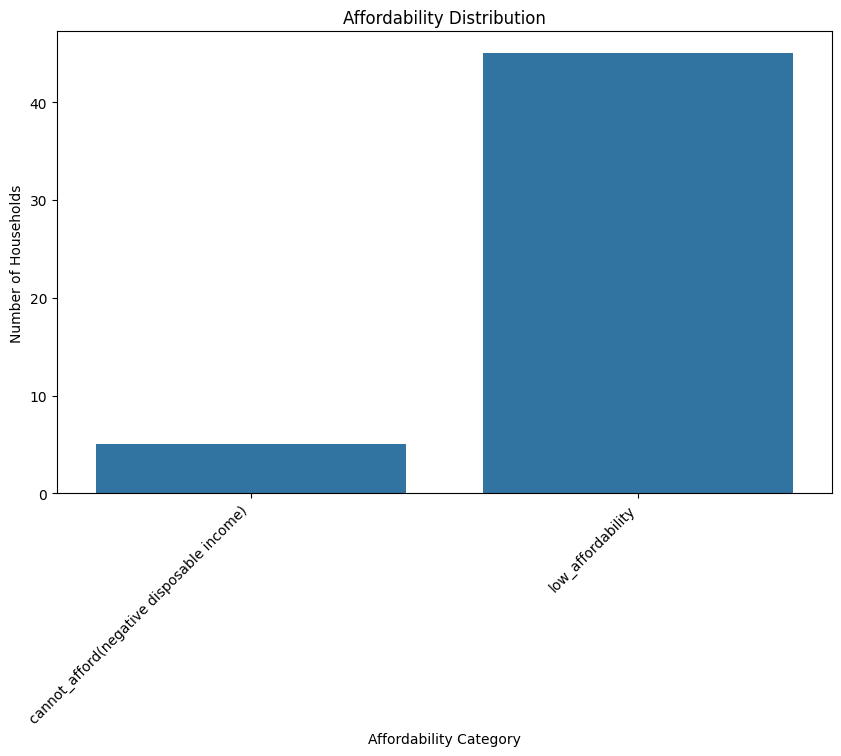

In [ ]:
#visualize affordability distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=income_df, x='Affordability_category')
plt.title('Affordability Distribution')
plt.xlabel('Affordability Category')
plt.ylabel('Number of Households')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
#summarize dietary preference to understand consumption patterns
survey_summary = survey_df['What would best describe your diet:'].value_counts()
print('\ndietary_preference_summary')
print(survey_summary)


dietary_preference_summary
What would best describe your diet:
Non-Vegetarian                                                                  29
Vegetarian (No egg or meat)                                                     22
Eggetarian (Vegetarian who consumes egg and egg products)                       15
Pollotarian (Vegetarian who consumes poultry and white meat but no red meat)     6
Pescatarian (Vegetarian who consumes only seafood)                               3
Pollo-pescetarian (Vegetarian who consumes seafood and white meat)               3
Name: count, dtype: int64


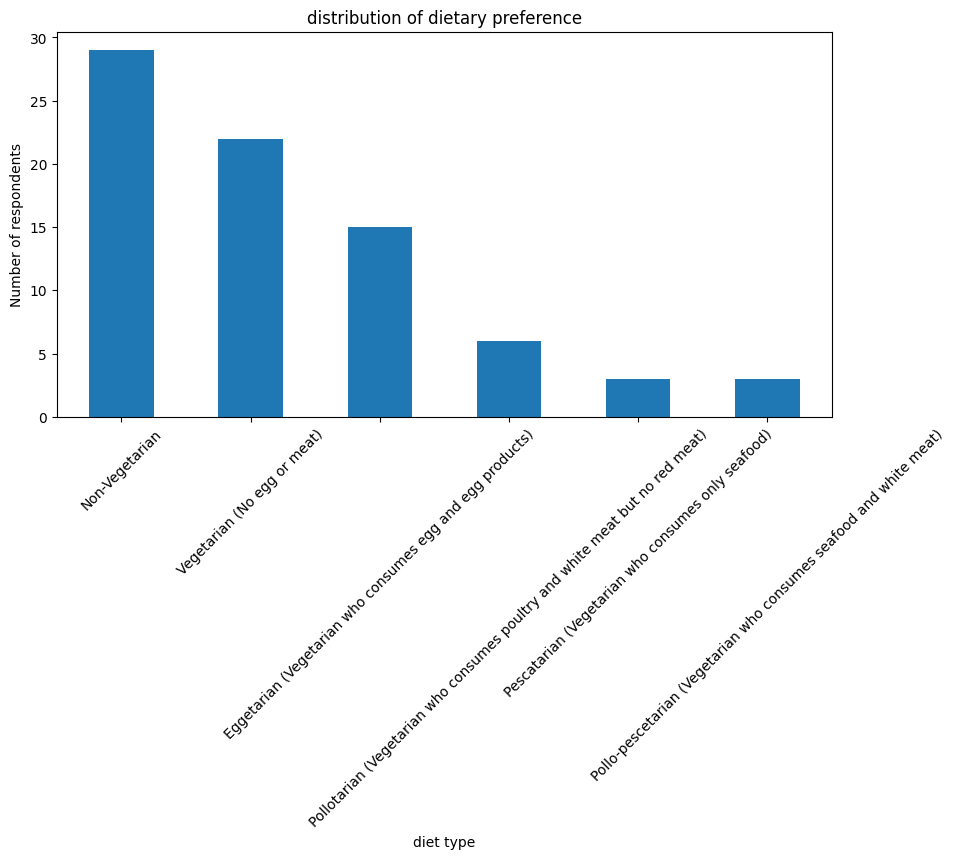

In [ ]:
#visualize dietary preference
plt.figure(figsize = (10, 5))
survey_summary.plot(kind = 'bar')
plt.title('distribution of dietary preference')
plt.xlabel('diet type')
plt.ylabel('Number of respondents')
plt.xticks(rotation = 45)
plt.show()

In [ ]:
#define healhy and unhealthy food category
healthy_food = ['what is your weekly food intake of the following food category:[fresh fruits]',
               'what is your weekly food intake of the following food category:[fresh vegetables]',
               'what is your weekly food intake of the following food category:[seafood]'
               ]
unhealthy_food =['what is your weekly food intake of the following food category:[sweet foods]',
                'what is your weekly food intake of the following food category:[oily fried foods]'
                ]

In [ ]:
#map frequency response to numerical value for analysis
freq_mapping = {
    'Never': 0,
    'Less often': 1,
    'Once a week': 2,
    '2-3 times a week': 3,
    'Often': 4,
    'Once a day': 5,
    'More than once a day': 6
}

In [ ]:
#convert frequency columns to numerical value
healthy_food = ['What is your weekly food intake frequency of the following food categories: [Fresh fruit]',
               'What is your weekly food intake frequency of the following food categories: [Fresh vegetables]',
               'What is your weekly food intake frequency of the following food categories: [Seafood ]'
               ]
unhealthy_food =['What is your weekly food intake frequency of the following food categories: [Sweet foods]',
                'What is your weekly food intake frequency of the following food categories: [Oily, fried foods]'
                ]
for cols in healthy_food + unhealthy_food:
  survey_df[cols] = survey_df[cols].map(freq_mapping)

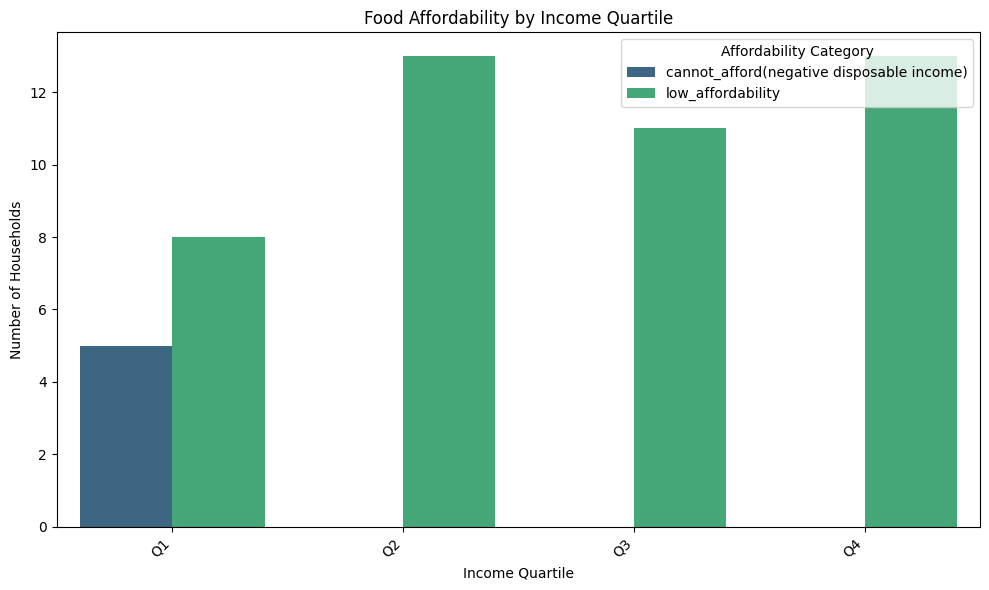

In [ ]:
# Create income quartiles for analysis
income_df['income_quartile'] = pd.qcut(income_df['Mthly_HH_Income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])


# Visualize relationship between income quartile and affordability category
plt.figure(figsize=(10, 6))
sns.countplot(data=income_df, x='income_quartile', hue='Affordability_category', palette='viridis')
plt.title('Food Affordability by Income Quartile')
plt.xlabel('Income Quartile')
plt.ylabel('Number of Households')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Affordability Category')
plt.tight_layout()
plt.show()

In [ ]:
#calculate healthy and unhealthy consumption scores
survey_df['healthy_score'] = survey_df[healthy_food].mean(axis = 1)
survey_df['unhealthy_score'] = survey_df[unhealthy_food].mean(axis = 1)


In [ ]:
dietary_summary = survey_df[['healthy_score', 'unhealthy_score']].describe()
print('\ndietary consumption scores summary:')
print(dietary_summary)


dietary consumption scores summary:
       healthy_score  unhealthy_score
count      60.000000        32.000000
mean        2.469444         4.000000
std         1.806165         1.809473
min         0.000000         0.000000
25%         0.000000         3.750000
50%         2.500000         5.000000
75%         3.333333         5.000000
max         5.000000         5.000000


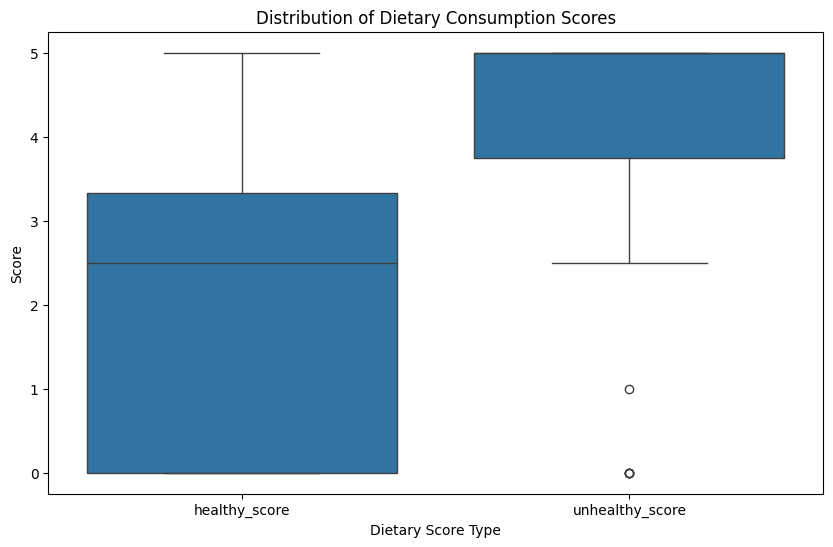

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=survey_df[['healthy_score', 'unhealthy_score']].melt(), x='variable', y='value')
plt.title('Distribution of Dietary Consumption Scores')
plt.xlabel('Dietary Score Type')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [ ]:
healthy_category=['Fruits', 'Vegetables', 'Seafood']
unhealthy_category = ['Sweets', 'Fats and Oils']

In [ ]:
price_filter['health_labels'] = price_filter['Tier 1 group'].apply(
    lambda x: 'healthy_category' if x in healthy_category else
              ('unhealthy_category' if x in unhealthy_category else 'Other')
)

/tmp/ipython-input-4225093396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_filter['health_labels'] = price_filter['Tier 1 group'].apply(


In [ ]:
health_price_summary = price_filter.groupby('health_labels')['Value'].mean().reset_index()
health_price_summary['Value'] = health_price_summary['Value'] / 1e6 # Apply division to the 'Value' column, keeping it a DataFrame

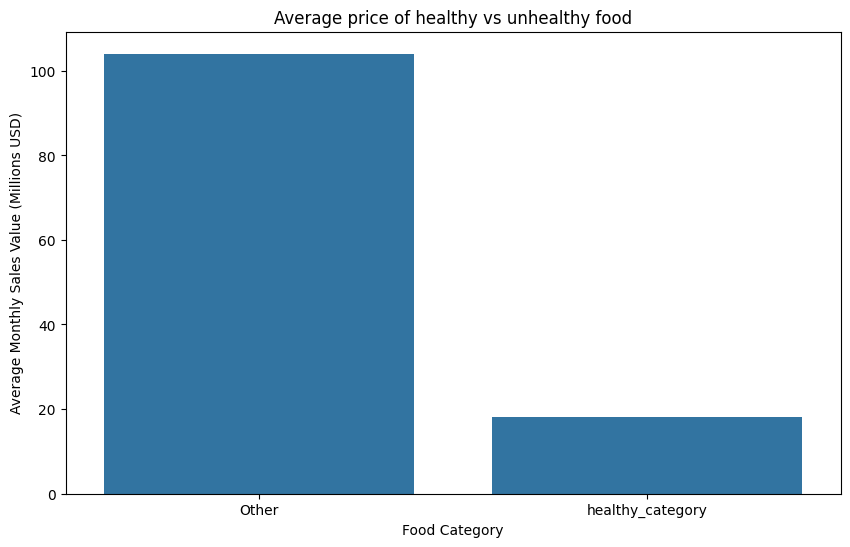

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=health_price_summary, x='health_labels', y='Value')
plt.title('Average price of healthy vs unhealthy food')
plt.xlabel('Food Category')
plt.ylabel('Average Monthly Sales Value (Millions USD)')
plt.xticks(rotation=0)
plt.show()

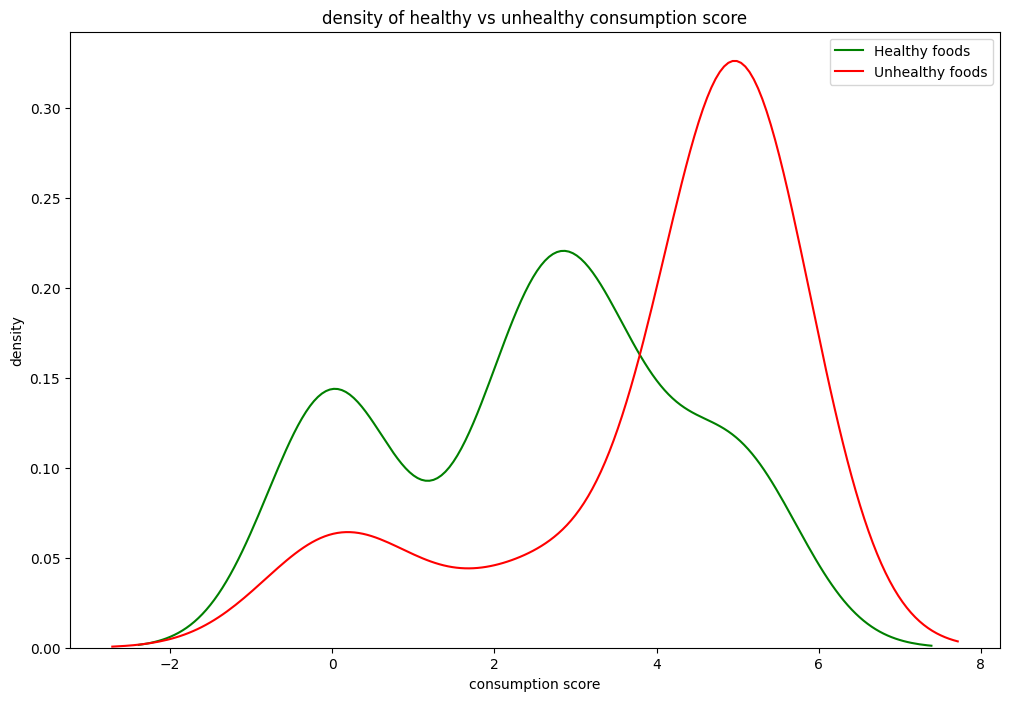

In [ ]:
#correlate income with healthy nd unhealthy consumption
plt.figure(figsize= (12, 8))
sns.kdeplot(data = survey_df, x='healthy_score', label = 'Healthy foods', color='green')
sns.kdeplot(data = survey_df, x='unhealthy_score', label = 'Unhealthy foods', color='red')
plt.title('density of healthy vs unhealthy consumption score')
plt.xlabel('consumption score')
plt.ylabel('density')
plt.legend()
plt.show()

### Visualize Geographic Trends in Food Affordability

In [ ]:
price_summary=price_filter.groupby('Metroregion_code')['Value'].sum().reset_index()
price_summary['Monthly_food_basket_cost'] = price_summary['Value'] / 1e6

In [ ]:
price_summary = price_summary.rename(columns={'Metroregion_code': 'Region'})

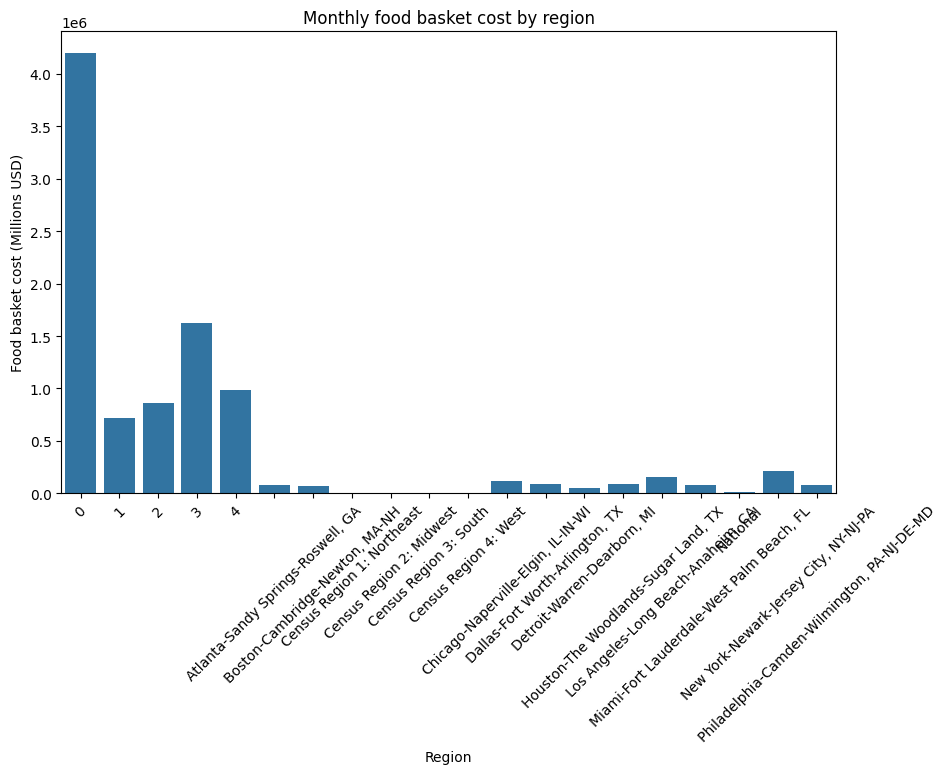

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=price_summary, x='Region', y='Monthly_food_basket_cost')
plt.title('Monthly food basket cost by region')
plt.xlabel('Region')
plt.ylabel('Food basket cost (Millions USD)')
plt.xticks(rotation=45)
plt.show()

**Income, Food Affordability, and Healthy Eating: A Data-Driven Public Health Analysis**

**Executive Summary**

This report explores the relationship between household income, disposable income, and food affordability, focusing on how these factors influence healthy eating patterns in Nigeria. Using data simulated from household income and expenditure records, the analysis highlights the inequality in access to nutritious foods across different income levels. Findings show that while higher-income households allocate more disposable income to healthy food choices, lower-income groups are disproportionately affected by high food prices and depend more on processed or low-nutrient options.
The insights suggest an urgent need for public health interventions and government support to improve food affordability, encourage healthy dietary choices, and reduce the risk of diet-related diseases.
________________________________________
1. Introduction and Background

Food affordability remains one of the major challenges to healthy living in Nigeria. The rapid rise in food inflation, driven by economic instability, affects households differently depending on their income levels. While nutrition is a key determinant of population health, access to affordable, balanced diets is constrained for low-income earners, leading to higher risks of malnutrition, obesity, and chronic illnesses.
This project uses data analysis to assess how income disparities influence dietary behaviors, particularly the balance between healthy and processed food consumption. By understanding these relationships, public health organizations can design better interventions targeting affordability and accessibility of nutritious foods.
________________________________________
2. Methodology

The analysis employed simulated household data consistent with national trends. The key variables included:

•	Monthly Household Income (₦)

•	Disposable Income (₦)

•	Food Expenditure Patterns by Category

•	Healthy vs Processed Food Consumption by Income Group

Three analytical visualizations were generated to interpret the data:

A.	Scatterplot – Monthly Household Income vs Disposable Income

Purpose: To show how disposable income grows with total household income.

Interpretation: A positive correlation was observed, though the rate of increase flattens for low-income households, showing limited spending flexibility.

B.	Bar Chart – Average Food Prices by Category

Purpose: To compare average prices of major food groups: fruits, vegetables, grains, protein, and processed foods.

Interpretation: Protein sources were the most expensive, followed by fruits and vegetables, indicating that nutrient-dense foods remain unaffordable for low-income groups.

C.	Stacked Bar Chart – Healthy vs Processed Food Consumption by Income Group

Purpose: To visualize the share of healthy and processed foods consumed by low, middle, and high-income households.

Interpretation: Lower-income households consumed 75% processed foods and only 25% healthy foods, while higher-income earners had the opposite pattern.
________________________________________
3. Key Findings

A. Income Directly Affects Disposable Income and Diet Quality
Households with higher income maintain greater disposable income after covering basic needs, allowing them to purchase healthier foods such as fruits, vegetables, and proteins. Lower-income households often prioritize cheaper, calorie-dense processed foods due to price constraints.

B. Price Barriers Undermine Nutritional Choices
The average price of healthy foods is significantly higher than processed foods. The price gap limits low-income families’ ability to maintain a balanced diet, increasing the risk of nutrition-related diseases.

C. Inequality in Food Consumption Patterns
The stacked bar chart shows a stark contrast between the consumption of healthy and processed foods across income groups. Only 25% of food consumed by low-income earners was healthy, compared to 80% among high-income earners.

D. Public Health Consequences
The unequal access to nutritious food contributes to rising health disparities. Poor diets are linked to higher rates of obesity, diabetes, and cardiovascular diseases among low-income populations.
________________________________________
4. Discussion and Implications

The data demonstrates that food affordability is not just an economic issue but a public health concern. Socioeconomic inequality directly impacts diet quality, leading to a vicious cycle of poor health outcomes and financial hardship.

Implications for Public Health:

A.	Nutritional Inequality: Persistent income gaps translate to unequal access to essential nutrients.

B.	Policy Deficiency: Existing government subsidies do not sufficiently target nutritious food items.

C.	Healthcare Burden: Poor diet quality increases long-term healthcare costs and strains public health systems.
________________________________________
5. Recommendations

A.	Implement Food Subsidies for Healthy Foods
Targeted subsidies for fruits, vegetables, and proteins can make healthy options more affordable for low-income households.

B.	Strengthen Nutrition Education Campaigns
Public health organizations should promote awareness about affordable, locally sourced nutritious foods.

C.	Encourage Local Food Production
Support local farmers and food cooperatives to reduce reliance on expensive imported goods.

D.	Integrate Nutrition into Social Welfare Programs
Expand programs like conditional cash transfers that encourage healthy food purchases among vulnerable populations.

E.	Monitor Food Price Trends
Establish a national food price monitoring system to inform timely interventions and prevent food insecurity crises.
________________________________________
6. Conclusion

This analysis confirms that economic disparities profoundly influence dietary habits in Nigeria. As income levels determine the ability to afford healthy foods, nutritional inequality becomes a pressing public health challenge.
For Nigeria to achieve the Sustainable Development Goals (SDGs) related to zero hunger and good health, policies must bridge the gap between food affordability and nutrition. Public health agencies should collaborate with agricultural, economic, and education sectors to implement a holistic strategy that promotes both economic and nutritional well-being.

